# Classificação de Sementes de Cacau com CNN + SVM

## Trabalho Pedagógico Complementar - Machine Learning Aplicado 2

**Universidade do Estado do Amazonas - Escola Superior de Tecnologia**

**Docente:** Profª Elloá B. Guedes

**Integrantes:** Alexandre Silva, Cesar Braz, Ícaro Guimarães, Priscila Gonçalves.

---

## Objetivo

Implementar um sistema de classificação de sementes de cacau no teste de corte utilizando **Redes Neurais Convolucionais (CNNs)** pré-treinadas como extratoras automáticas de características visuais, combinadas com **Máquinas de Vetores de Suporte (SVMs)** como classificadores.

### Etapas Contempladas

Conforme solicitado no trabalho pedagógico:

1. **Análise Exploratória da Base de Dados** - Distribuição por classe, inspeção de qualidade e visualização
2. **Preparação de Dados** - Redimensionamento, normalização e partição holdout
3. **Extração de Características Visuais** - Todas as arquiteturas do trabalho correlato como extratoras
4. **Elaboração da Busca em Grade** - Múltiplos valores de C, kernel e gamma
5. **Execução dos Experimentos** - Tempo de treinamento, acurácia, precisão, revocação e F1-Score
6. **Análise dos Resultados** - Tabela descritiva, matrizes de confusão dos três melhores modelos

### Arquiteturas CNN

Conforme o trabalho de referência (Malcher & Guedes, 2022), as seguintes arquiteturas foram avaliadas:

| Trabalho de Referência | Implementação | Observação |
|------------------------|---------------|------------|
| Inception | InceptionV3 | Top 3 |
| VGG-16 | VGG16 | Top 3 |
| EfficientNetB0 | EfficientNetB0 | Top 3 |
| MobileNet | MobileNetV2 | - |
| EfficientNetB3 | EfficientNetB3 | - |
| LeNet | - | Não disponível no Keras |
| AlexNet | - | Não disponível no Keras |
| - | DenseNet121 | Alternativa adicional |

### Meta

Avaliar o desempenho da abordagem **CNN como extratora de características + SVM classificador** na tarefa de classificação de sementes de cacau, comparando os resultados com o baseline de **89,79%** obtido por Malcher & Guedes (2022) utilizando CNNs treinadas end-to-end.

---
## 1. Configuração do Ambiente

In [1]:
# Instalação de Dependências
!pip install -q tensorflow scikit-learn matplotlib seaborn pandas numpy pillow

print("Dependências instaladas com sucesso!")

Dependências instaladas com sucesso!


In [2]:
# Importação de Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    StackingClassifier,
    GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    train_test_split,
    cross_val_score,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from tensorflow.keras.applications import (
    VGG16, VGG19, ResNet50, InceptionV3, MobileNetV2,
    EfficientNetB0, EfficientNetB3, DenseNet121
)
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.models import Model
from PIL import Image
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Seed para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [3]:
# Montar o Google Drive
from google.colab import drive
drive.mount("/content/drive")
print("Drive montado!")

Mounted at /content/drive
Drive montado!


In [4]:
# ====================================================================#
# Caminho do Dataset no Google Drive                                  #
# Download do dataset https://data.mendeley.com/datasets/pcx7mj68yn/4 #
# Utilizado o "Enquadrado e Centralizado - Versão 1 - Método A"       #
# que tivemos o melhor resultado.                                     #
# ====================================================================#
DATASET_DIR = "/content/drive/MyDrive/ML2/Cacau6"

if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(f"Caminho não encontrado: {DATASET_DIR}")

# Constantes
BASELINE = 0.8979  # Baseline do trabalho de referência Malcher & Guedes (2022)
N_REPETITIONS = 5  # Número de repetições do holdout (igual ao trabalho de referência)

print(f"Dataset encontrado: {DATASET_DIR}")

Dataset encontrado: /content/drive/MyDrive/ML2/Cacau6


---
## 2. Análise Exploratória de Dados (EDA)

In [37]:
# Identificar classes do dataset
classes = sorted([d for d in os.listdir(DATASET_DIR)
                  if os.path.isdir(os.path.join(DATASET_DIR, d))])

print(f"{'='*60}")
print(f"CLASSES ENCONTRADAS NO DATASET")
print(f"{'='*60}")
for i, cls in enumerate(classes, 1):
    print(f"{i:2d}. {cls}")
print(f"{'='*60}")
print(f"Total de classes: {len(classes)}")

CLASSES ENCONTRADAS NO DATASET
 1. Agglutinated
 2. Brittle
 3. Compartmentalized_Brown
 4. Compartmentalized_PartiallyPurple
 5. Compartmentalized_Purple
 6. Compartmentalized_Slaty
 7. Compartmentalized_White
 8. Flattened
 9. Moldered
10. Plated_Brown
11. Plated_PartiallyPurple
12. Plated_Purple
13. Plated_Slaty
14. Plated_White
Total de classes: 14



 DISTRIBUIÇÃO DE IMAGENS POR CLASSE
Agglutinated                       :  100 imagens ( 7.14%)
Brittle                            :  100 imagens ( 7.14%)
Compartmentalized_Brown            :  100 imagens ( 7.14%)
Compartmentalized_PartiallyPurple  :  100 imagens ( 7.14%)
Compartmentalized_Purple           :  100 imagens ( 7.14%)
Compartmentalized_Slaty            :  100 imagens ( 7.14%)
Compartmentalized_White            :  100 imagens ( 7.14%)
Flattened                          :  100 imagens ( 7.14%)
Moldered                           :  100 imagens ( 7.14%)
Plated_Brown                       :  100 imagens ( 7.14%)
Plated_PartiallyPurple             :  100 imagens ( 7.14%)
Plated_Purple                      :  100 imagens ( 7.14%)
Plated_Slaty                       :  100 imagens ( 7.14%)
Plated_White                       :  100 imagens ( 7.14%)
TOTAL DE IMAGENS: 1400
INTERVALO POR CLASSE: 100 a 100 imagens


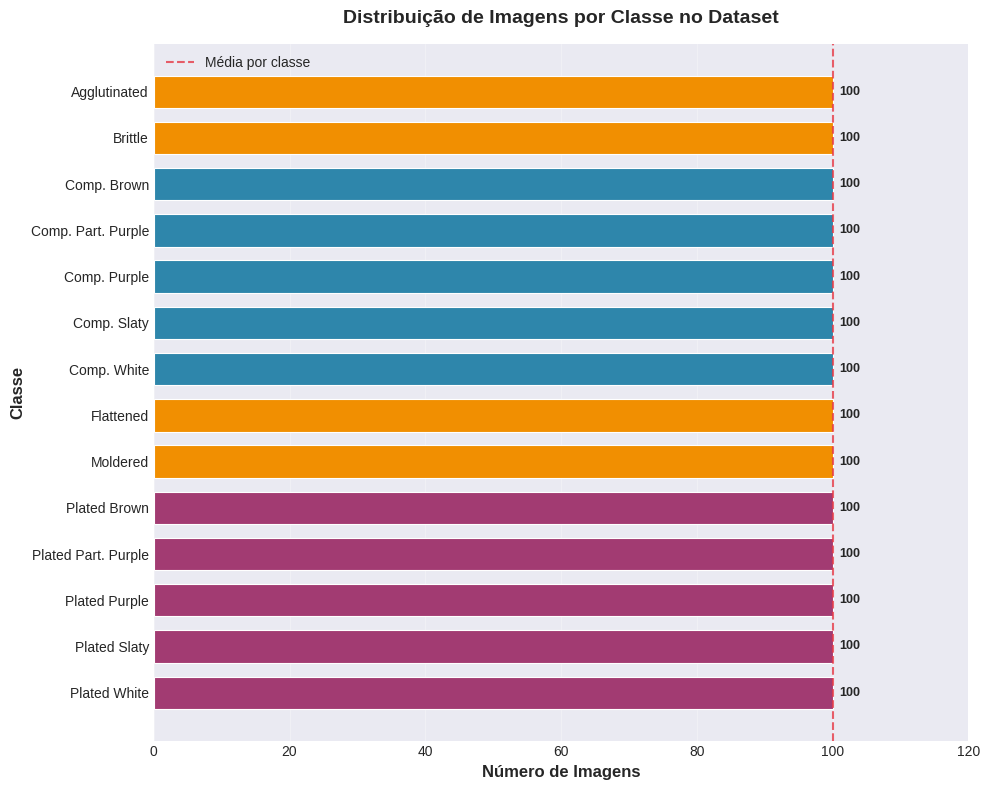


 Gráfico salvo: distribuicao_classes.png


In [68]:
# EDA — DISTRIBUIÇÃO DE IMAGENS POR CLASSE

print("\n" + "="*70)
print(" DISTRIBUIÇÃO DE IMAGENS POR CLASSE")
print("="*70)


# Leitura e organização do dataset


data = []

for cls in classes:
    class_path = os.path.join(DATASET_DIR, cls)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for img in images:
        data.append({
            "class": cls,
            "path": os.path.join(class_path, img),
            "filename": img
        })

df = pd.DataFrame(data)


# Contagem e percentual por classe


class_counts = df["class"].value_counts().sort_index()

for cls, count in class_counts.items():
    pct = count / len(df) * 100
    print(f"{cls:35s}: {count:4d} imagens ({pct:5.2f}%)")

print("="*70)
print(f"TOTAL DE IMAGENS: {len(df)}")
print(f"INTERVALO POR CLASSE: {class_counts.min()} a {class_counts.max()} imagens")
print("="*70)


# Visualização — barras horizontais

fig, ax = plt.subplots(figsize=(10, 8))

# Cores por categoria de defeito
colors = []
for cls in class_counts.index:
    if 'Compartmentalized' in cls:
        colors.append('#2E86AB')  # Azul
    elif 'Plated' in cls:
        colors.append('#A23B72')  # Rosa
    else:
        colors.append('#F18F01')  # Laranja

y = np.arange(len(class_counts))
values = class_counts.values
labels = [
    c.replace('_', ' ')
     .replace('Compartmentalized', 'Comp.')
     .replace('PartiallyPurple', 'Part. Purple')
    for c in class_counts.index
]

bars = ax.barh(
    y,
    values[::-1],
    color=colors[::-1],
    edgecolor='white',
    linewidth=0.8,
    height=0.7
)

ax.set_yticks(y)
ax.set_yticklabels(labels[::-1], fontsize=10)
ax.set_xlabel('Número de Imagens', fontsize=12, fontweight='bold')
ax.set_ylabel('Classe', fontsize=12, fontweight='bold')
ax.set_title(
    'Distribuição de Imagens por Classe no Dataset',
    fontsize=14,
    fontweight='bold',
    pad=15
)

# Linha de referência (balanceamento aproximado)
ax.axvline(
    x=class_counts.mean(),
    color='#E63946',
    linestyle='--',
    linewidth=1.5,
    alpha=0.8,
    label='Média por classe'
)

# Rótulos nas barras
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f'{int(width)}',
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha='left',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_xlim(0, max(values) + 20)
ax.xaxis.grid(True, linestyle='-', alpha=0.3)
ax.yaxis.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

plt.tight_layout()
plt.savefig('distribuicao_classes.png', dpi=72, bbox_inches='tight', facecolor='white')
plt.show()

print("\n Gráfico salvo: distribuicao_classes.png")


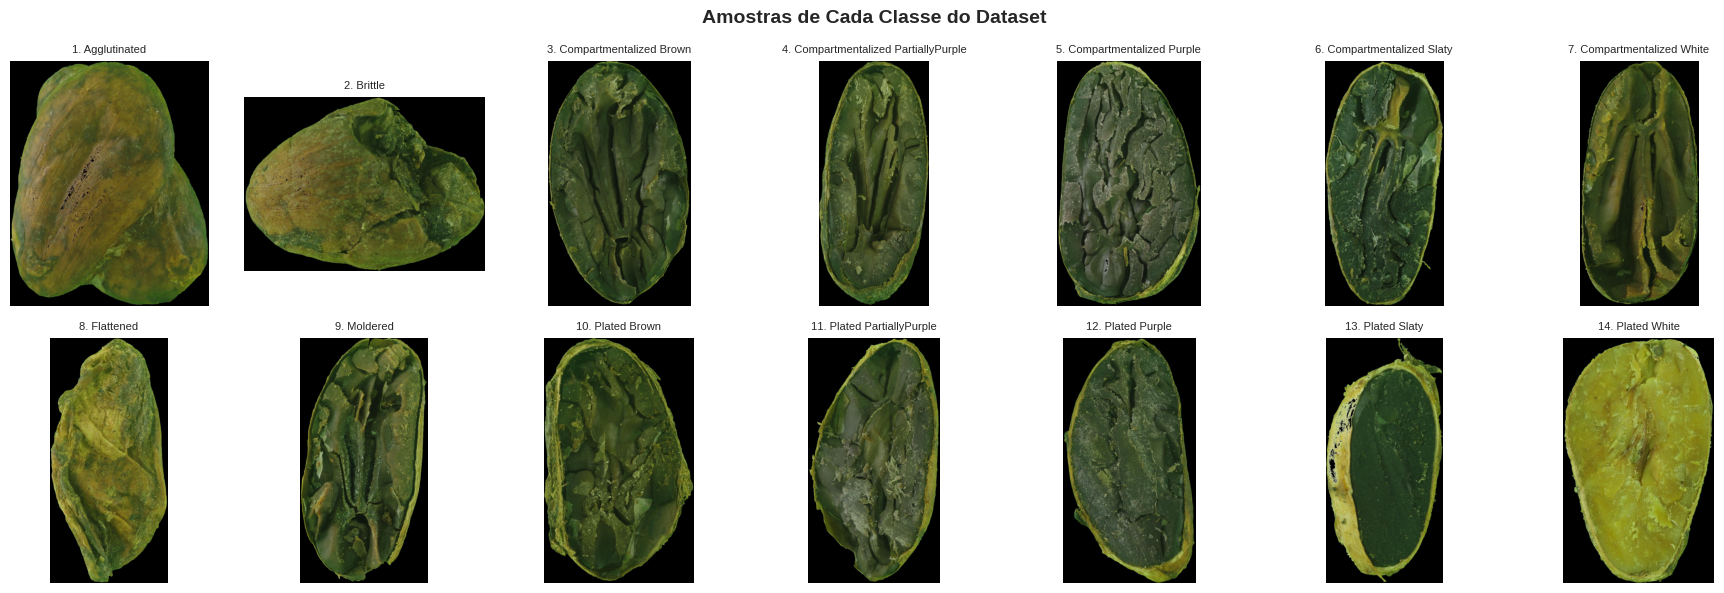


 Gráfico salvo: amostras_classes.png


In [14]:
# Visualização de amostras por classe
fig, axes = plt.subplots(2, 7, figsize=(18, 6))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    sample_path = df[df['class'] == cls]['path'].iloc[0]
    img = Image.open(sample_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f"{idx+1}. {cls.replace('_', ' ')}", fontsize=8)
    axes[idx].axis('off')

plt.suptitle('Amostras de Cada Classe do Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('amostras_classes.png', dpi=72, bbox_inches='tight')
plt.show()
print("\n Gráfico salvo: amostras_classes.png")

In [69]:
# Inspeção de qualidade e formato das imagens
print("\n INSPEÇÃO DE QUALIDADE DAS IMAGENS")
print("="*60)

# Analisar amostras de cada classe
quality_info = []

for cls in classes:
    class_path = os.path.join(DATASET_DIR, cls)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:5]  # Amostra de 5

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        with Image.open(img_path) as img:
            quality_info.append({
                'class': cls,
                'filename': img_name,
                'width': img.size[0],
                'height': img.size[1],
                'mode': img.mode,
                'format': img.format
            })

quality_df = pd.DataFrame(quality_info)

print(f"\n DIMENSÕES DAS IMAGENS:")
print(f"   Largura  - Min: {quality_df['width'].min()}, Max: {quality_df['width'].max()}, Média: {quality_df['width'].mean():.0f}")
print(f"   Altura   - Min: {quality_df['height'].min()}, Max: {quality_df['height'].max()}, Média: {quality_df['height'].mean():.0f}")

print(f"\n MODO DE COR:")
for mode, count in quality_df['mode'].value_counts().items():
    print(f"   {mode}: {count} imagens")

print(f"\n FORMATO:")
for fmt, count in quality_df['format'].value_counts().items():
    print(f"   {fmt}: {count} imagens")

print("\n" + "="*60)
print("Conclusão: Dataset com imagens de boa qualidade, formato consistente")


 INSPEÇÃO DE QUALIDADE DAS IMAGENS

 DIMENSÕES DAS IMAGENS:
   Largura  - Min: 899, Max: 1971, Média: 1215
   Altura   - Min: 883, Max: 2627, Média: 2076

 MODO DE COR:
   RGB: 70 imagens

 FORMATO:
   JPEG: 70 imagens

Conclusão: Dataset com imagens de boa qualidade, formato consistente
